In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Salary_Data.csv')

In [4]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [5]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [7]:
# check the linearlity

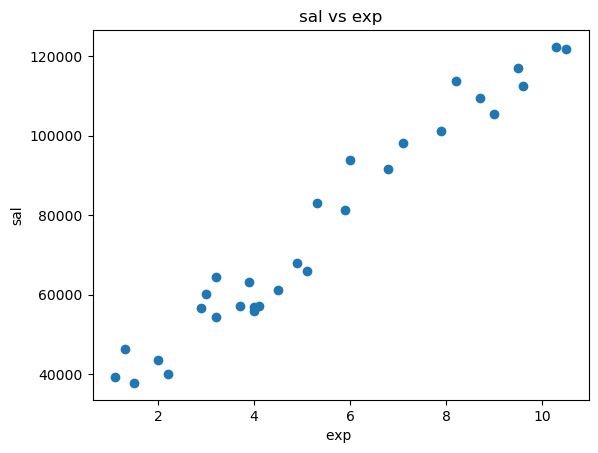

In [8]:
plt.title("sal vs exp")
plt.xlabel("exp ")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'],df['Salary']);

In [9]:
x = df[['YearsExperience']]
y = df['Salary']

In [10]:
y;

In [11]:
# cross val

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=0)

In [14]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((22, 1), (22,), (8, 1), (8,))

In [15]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# val of m 
lr.coef_

array([9379.71049195])

In [17]:
lr.intercept_

np.float64(26986.691316737248)

In [18]:
y_pred = lr.predict(X_test)

In [19]:
pd.DataFrame({'actual': y_test,
             'pred': y_pred})

,actual,pred
2,37731.0,41056.257055
28,122391.0,123597.709384
13,57081.0,65443.504334
10,63218.0,63567.562235
26,116969.0,116093.940990
24,109431.0,108590.172597
27,112635.0,117031.912039
11,55794.0,64505.533285


In [20]:
# plot the best fit line  on the  previous scatter chart

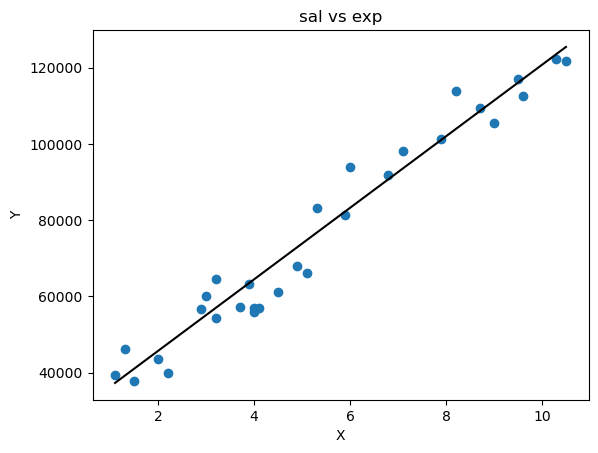

In [21]:

plt.xlabel("X")
plt.ylabel("Y")
plt.title("sal vs exp")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x, lr.predict(x), color = 'black');


In [22]:
from sklearn.metrics import mean_absolute_error

In [23]:
mean_absolute_error(y_test,y_pred)

3508.5455930660555

In [24]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9779208335417602

#polynomial reg

In [25]:
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [26]:
# create polynomial features 

In [27]:
from sklearn.preprocessing import PolynomialFeatures

In [28]:
poly =PolynomialFeatures(degree= 2)

In [29]:
x_poly = poly.fit_transform(x)

In [30]:
x_poly

array([[  1.  ,   1.1 ,   1.21],
       [  1.  ,   1.3 ,   1.69],
       [  1.  ,   1.5 ,   2.25],
       [  1.  ,   2.  ,   4.  ],
       [  1.  ,   2.2 ,   4.84],
       [  1.  ,   2.9 ,   8.41],
       [  1.  ,   3.  ,   9.  ],
       [  1.  ,   3.2 ,  10.24],
       [  1.  ,   3.2 ,  10.24],
       [  1.  ,   3.7 ,  13.69],
       [  1.  ,   3.9 ,  15.21],
       [  1.  ,   4.  ,  16.  ],
       [  1.  ,   4.  ,  16.  ],
       [  1.  ,   4.1 ,  16.81],
       [  1.  ,   4.5 ,  20.25],
       [  1.  ,   4.9 ,  24.01],
       [  1.  ,   5.1 ,  26.01],
       [  1.  ,   5.3 ,  28.09],
       [  1.  ,   5.9 ,  34.81],
       [  1.  ,   6.  ,  36.  ],
       [  1.  ,   6.8 ,  46.24],
       [  1.  ,   7.1 ,  50.41],
       [  1.  ,   7.9 ,  62.41],
       [  1.  ,   8.2 ,  67.24],
       [  1.  ,   8.7 ,  75.69],
       [  1.  ,   9.  ,  81.  ],
       [  1.  ,   9.5 ,  90.25],
       [  1.  ,   9.6 ,  92.16],
       [  1.  ,  10.3 , 106.09],
       [  1.  ,  10.5 , 110.25]])

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x_poly,y,random_state=0)

In [32]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = lr.predict(x_test)

In [34]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.977895282415858

C:\Users\yr714\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


ValueError: X has 1 features, but LinearRegression is expecting 3 features as input.

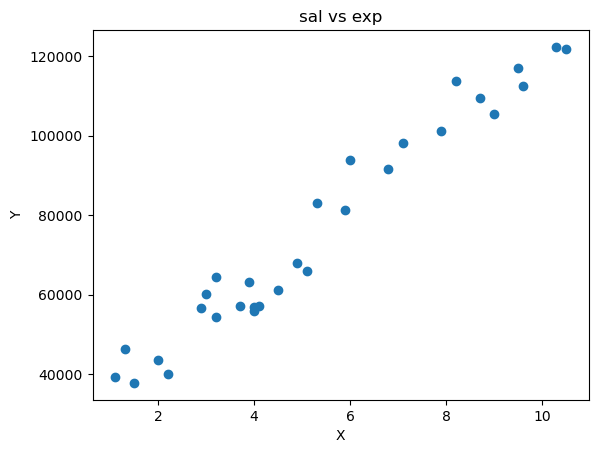

In [38]:
plt.xlabel("X")
plt.ylabel("Y")
plt.title("sal vs exp")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x_poly, lr.predict (x), color = 'black');
